# <u><center>Machine learning model application on loan data set</center></u>

## Introduction

In this, we perform:
* Data Cleaning
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Logistic Regression Model
* Accuracy & Confusion Matrix Evaluation

Since the output (Loan_Status) has only two classes (Y/N), this is a Binary Classification problem, and Logistic Regression is suitable.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load Dataset

In [2]:
df = pd.read_csv("loan_data_set.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Basic Data Understanding

#### -> Shape of Data

In [3]:
df.shape

(614, 13)

#### -> Column Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#### -> Statistical Summary

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Exploratory Data Analysis (EDA)

#### -> Missing Values Check

In [20]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#### -> Target Variable Distribution

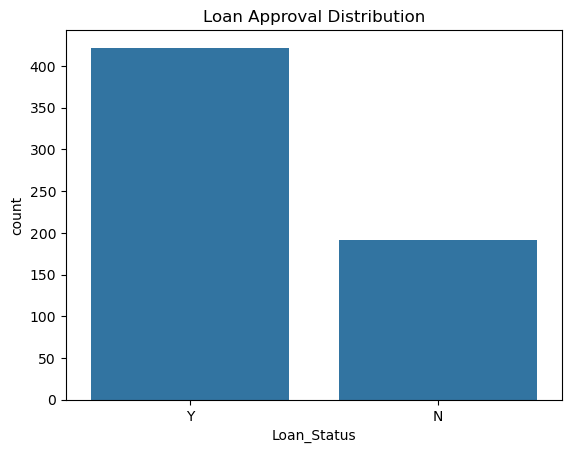

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [7]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

df['Loan_Status'].value_counts()

#### -> Gender vs Loan Status

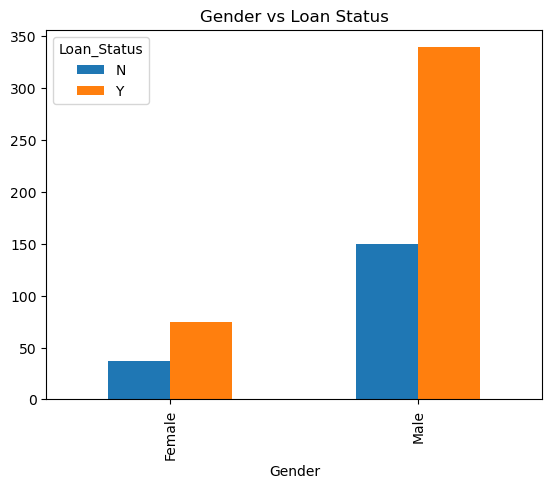

In [8]:
pd.crosstab(df['Gender'], df['Loan_Status']).plot(kind='bar')
plt.title("Gender vs Loan Status")
plt.show()

#### -> Education vs Loan Status

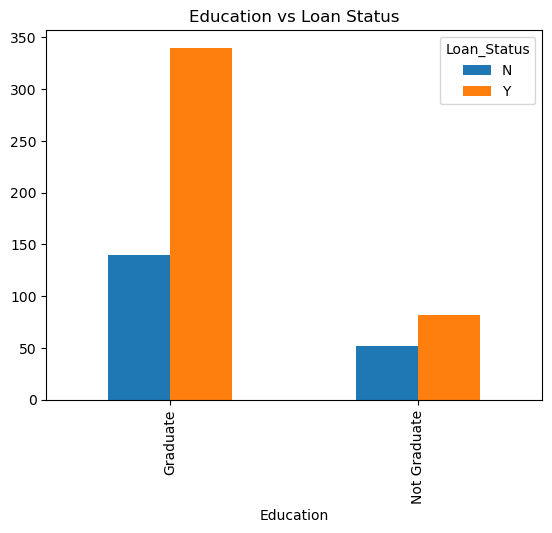

In [9]:
pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar')
plt.title("Education vs Loan Status")
plt.show()

##### <u>Insight :</u>
* <mark>Graduates have higher approval probability.</mark>

#### -> Credit History vs Loan Status (Very Important)

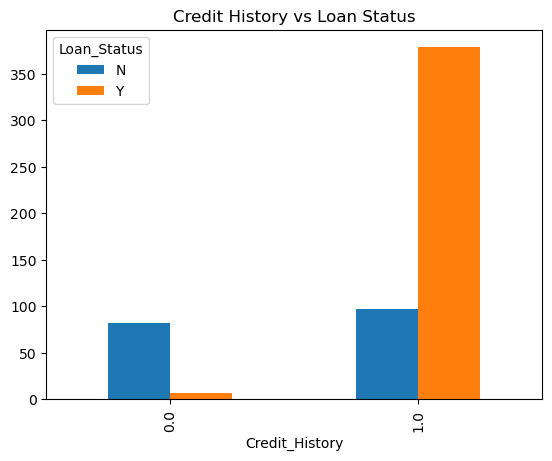

In [14]:
pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(kind='bar')
plt.title("Credit History vs Loan Status")
plt.show()

##### <u>Insight :</u>
* Strong relationship usually observed
* Good credit history → high approval
* Poor credit history → rejection

#### -> Income Distribution

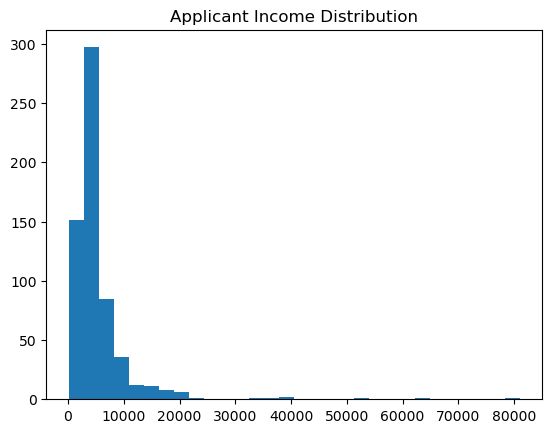

In [15]:
plt.hist(df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

##### <u>Insight :</u>
* Most applicants are middle income.
* Few very high income outliers present.

#### -> Loan Amount Distribution

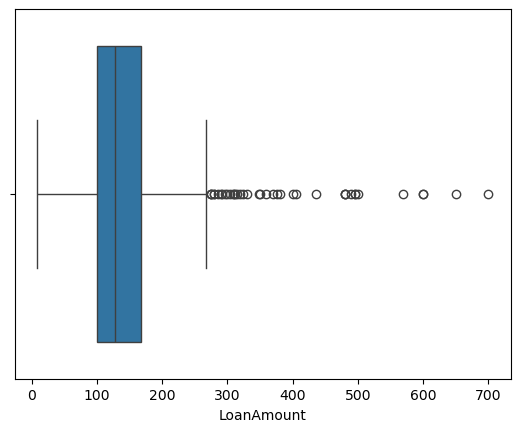

In [16]:
sns.boxplot(x=df['LoanAmount'])
plt.show()

##### <u>Insight :</u>
* Detects outliers
* Large loan amounts may affect approval

### Data Cleaning & Preprocessing

#### -> Handle Missing Values

In [19]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1536\1004411449.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_1536\1004411449.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

##### <u>Insight :</u>
* Mode → categorical
* Median → numeric

#### -> Encode Categorical Variables

In [21]:
le = LabelEncoder()

cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status','Dependents']

for col in cols:
    df[col] = le.fit_transform(df[col])

* Machine learning models only accept numbers, so encoding is required.

### Feature Selection

In [22]:
X = df.drop(['Loan_ID','Loan_Status'], axis=1)
y = df['Loan_Status']

* X → input features
* y → target variable

### Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

* 80% training
* 20% testing
* Helps evaluate generalization

### Logistic Regression Model

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Predictions

In [25]:
y_pred = model.predict(X_test)

### Model Evaluation

#### -> Accuracy

In [26]:
accuracy_score(y_test, y_pred)

0.7886178861788617

#### -> Confusion Matrix

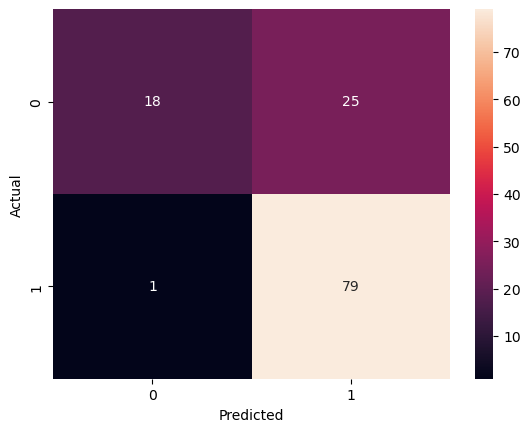

In [27]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### -> Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## <u>Final Insights & Conclusion :</u>

### -> Key Insights from EDA

After performing exploratory data analysis on the loan dataset, some clear patterns were observed.
* Most of the loan applications are <mark>approved</mark>, while fewer are rejected.
* <mark>Credit History</mark> has the strongest impact on loan approval. Applicants with good credit history are much more likely to get their loans approved.
* <mark>Graduates</mark> seem to have slightly better approval rates compared to non-graduates.
* <mark>Income</mark> plays an important role. Applicants with higher income generally have better chances of approval.
* The income and loan amount distributions are <mark>skewed with some outliers</mark>, which may affect model predictions.
* Other features like gender and property area show some variation but are not major deciding factors.

Overall, <mark>credit history and income appear</mark> to be the most important features influencing the decision.


### ->Model Performance

After training the <mark>Logistic Regression model</mark>:
* Accuracy obtained ≈ <mark>78.8%</mark>
* The model correctly predicts <mark>most approved loans</mark>.
* From the confusion matrix, we can see that:
      - Many approvals are predicted correctly
      - Some rejected loans are <mark>misclassified as approved</mark>

From the classification report:
* <mark>Recall for approved loans is high</mark>
* Recall for rejected loans is comparatively lower

This means the model is <mark>better at identifying approvals than rejections</mark>.


### -> Conclusion

In this project, we applied <mark>Logistic Regression</mark> to predict loan approval based on applicant details. After cleaning the data, performing EDA, and training the model, we achieved <mark>satisfactory results</mark>.

Logistic Regression works well for this <mark>binary classification problem</mark> and gives decent accuracy. The model can help banks quickly filter applications and support decision-making.

With further improvements like feature engineering or using more advanced models, the performance can be increased even more.

Overall, the project helped in understanding the <mark>complete machine learning workflow from data cleaning to model evaluation</mark>.